# Curaduría y Preprocesamiento de Datos — Proyecto BI-RADS
**Sistema de Auditoría de Coherencia Diagnóstica con BETO**  
Doctorado en Ciencias e Ingeniería para la Salud — Universidad de Valparaíso, 2025  
Autores: Robinson Moreno - Sebastián Inostroza


| Sección | Contenido |
|---------|-----------|
| 1 | Verificación de entorno y librerías |
| 2 | Carga del dataset |
| 3 | Inspección inicial |
| 4 | Análisis de valores faltantes |
| 5 | Tratamiento de nulos |
| 6 | Preprocesamiento de texto |
| 7 | Distribución de clases BI-RADS (EDA) |
| 8 | EDA de variables clínicas estructuradas |
| 9 | Análisis de tokens BETO + umbral 512 |
| 10 | Detección de duplicados y riesgo de leakage |
| 11 | Construcción de columnas para modelos |
| 12 | División del dataset (train/val/test) |
| 13 | Pesos de clase para manejo del desbalance |
| 14 | Verificación visual de estratificación |
| 15 | Exportación trazable del dataset limpio |
| 16 | Resumen ejecutivo de curaduría |


## 1. Verificación de entorno y librerías

In [27]:
# Instalación de dependencias (ejecutar solo si es necesario)
# !pip install torch transformers scikit-learn pandas numpy matplotlib seaborn

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
import os
import hashlib
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import BertTokenizerFast

# ── Módulo de limpieza compartido (fuente única de verdad) ──
import sys
sys.path.append('..')   # el notebook vive en notebooks/, el módulo en src/
from src.preprocessing import (limpiar_texto, construir_inputs,
                               ABREVIATURAS, MAX_LENGTH, MODELO_BASE)

print(f"\u2705 PyTorch:        {torch.__version__}")
print(f"\u2705 Pandas:         {pd.__version__}")
print(f"\u2705 NumPy:          {np.__version__}")
print(f"\u2705 Transformers:   instalado correctamente")
print(f"\u2705 Modulo limpieza: src.preprocessing ({len(ABREVIATURAS)} abreviaturas, MAX_LENGTH={MAX_LENGTH})")
print(f"\n\U0001f5a5\ufe0f  GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU:           {torch.cuda.get_device_name(0)}")

# Paleta clínica global — Verde = zona segura (0-3) | Rojo = zona de riesgo (4-6)
COLORES = {0:'#4A9ECA', 1:'#5BBF8A', 2:'#5BBF8A',
           3:'#F0C040', 4:'#E8764A', 5:'#D94040', 6:'#8B1C1C'}
NOMBRES = {0:'Incompleto', 1:'Negativo', 2:'Benigno',
           3:'Prob. benigno', 4:'Sospechoso',
           5:'Alta sospecha', 6:'Maligno confirmado'}

os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
print("\n\U0001f4c1 Directorios '../results/figures/' y '../data/processed/' listos.")


✅ PyTorch:        2.12.0
✅ Pandas:         3.0.3
✅ NumPy:          2.4.6
✅ Transformers:   instalado correctamente
✅ Modulo limpieza: src.preprocessing (11 abreviaturas, MAX_LENGTH=256)

🖥️  GPU disponible: False

📁 Directorios '../results/figures/' y '../data/processed/' listos.


## 2. Carga del dataset

In [28]:
# Carga local (VSCode). El notebook vive en notebooks/, los datos en data/raw/.
csv_full = '../data/raw/BIRADS_radiology_reports.csv'
df = pd.read_csv(csv_full, sep=';', encoding='utf-8')

print(f"\u2705 Dataset cargado: {csv_full}")
print(f"\n\U0001f4d0 Shape: {df.shape[0]} filas \u00d7 {df.shape[1]} columnas")
print(f"\U0001f4cb Columnas: {list(df.columns)}")


✅ Dataset cargado: ../data/raw/BIRADS_radiology_reports.csv

📐 Shape: 4357 filas × 15 columnas
📋 Columnas: ['ID_R', 'Year', 'Month', 'Medical_Unit', 'Full_Report', 'LMP', 'Hormonal_Therapy', 'Family_History', 'Reason', 'Observations', 'Conclusion', 'Recommendations', 'BI-RADS', 'Age', 'Children']


## 3. Inspección inicial del dataset

In [29]:
print("📋 Primeras 2 filas (columnas clave):")
cols_clave = [c for c in ['ID_R', 'Year', 'Age', 'BI-RADS', 'Observations', 'Conclusion']
              if c in df.columns]
print(df[cols_clave].head(2).to_string())

print(f"\n📝 Ejemplo de texto real (primer informe):")
print(f"\nOBSERVACIONES:")
print(df['Observations'].iloc[0])
print(f"\nCONCLUSIÓN:")
print(df['Conclusion'].iloc[0])
print(f"\nBI-RADS ASIGNADO: {df['BI-RADS'].iloc[0]}")

print(f"\n📊 Tipos de datos:")
print(df.dtypes.to_string())


📋 Primeras 2 filas (columnas clave):
       ID_R  Year   Age  BI-RADS                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          Observations                                                                                                                                                                                                                  Conclusion
0  20190101  2019  48.0        0  MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y MEDIO LATERAL OBLÍCUAS\nNO SE OBS

## 4. Análisis de valores faltantes

In [30]:
print("🔍 Valores faltantes por columna:")
print("─" * 50)
hay_nulos = False
for col in df.columns:
    nulos = df[col].isna().sum()
    if nulos > 0:
        hay_nulos = True
        pct = nulos / len(df) * 100
        tipo = "🔴 CRÍTICO" if col in ['Observations','Conclusion','BI-RADS'] else "🟡 Secundario"
        print(f"  {col:25s}: {nulos:4d} ({pct:.2f}%)  {tipo}")
print("─" * 50)
if not hay_nulos:
    print("  ✅ No se detectaron valores faltantes en ninguna columna.")
print(f"\n  Total de registros: {len(df)}")


🔍 Valores faltantes por columna:
──────────────────────────────────────────────────
  LMP                      :  135 (3.10%)  🟡 Secundario
  Recommendations          :   10 (0.23%)  🟡 Secundario
  Age                      :   15 (0.34%)  🟡 Secundario
  Children                 :  125 (2.87%)  🟡 Secundario
──────────────────────────────────────────────────

  Total de registros: 4357


## 5. Tratamiento de valores faltantes

**Criterio aplicado:**
- Nulos en columnas de texto crítico (`Observations`, `Conclusion`): **eliminación de fila** — un informe sin texto no puede entrenarse.
- Nulos en variables clínicas numéricas (`Age`): **imputación por mediana** — preserva registros sin introducir sesgo de media.


In [31]:
n_antes = len(df)

# Nulos en texto (crítico): eliminar la fila completa
df = df[df['Observations'].notna() & df['Conclusion'].notna()].copy()
n_tras_texto = len(df)

# Nulos en Age: imputar mediana (calculada sobre todo el conjunto pre-split)
for col in ['Age']:
    if col in df.columns and df[col].isna().any():
        mediana = df[col].median()
        n_imputados = df[col].isna().sum()
        df[col] = df[col].fillna(mediana)
        print(f"  ✏️  '{col}': {n_imputados} nulos imputados con mediana = {mediana:.0f} años")

eliminados = n_antes - n_tras_texto
print(f"\n🧹 Registros eliminados por nulos en texto: {eliminados}")
print(f"   Dataset antes:  {n_antes}")
print(f"   Dataset después: {len(df)}")
print(f"   Pérdida: {eliminados/n_antes*100:.2f}%")


  ✏️  'Age': 15 nulos imputados con mediana = 51 años

🧹 Registros eliminados por nulos en texto: 0
   Dataset antes:  4357
   Dataset después: 4357
   Pérdida: 0.00%


## 6. Preprocesamiento de texto clínico

**Pasos aplicados:**
1. Normalización de saltos de línea y tabuladores → espacio
2. Colapso de guiones repetidos → espacio
3. Conversión a minúsculas
4. Expansión de abreviaturas anatómicas clínicas del dominio mamario
5. Eliminación de caracteres no útiles (conservando acentos y puntuación clínica)
6. Colapso de espacios múltiples


In [32]:
# La limpieza vive ahora en src/preprocessing.py (fuente unica de verdad).
# construir_inputs() genera obs_clean, concl_clean, texto_input y auditor_input
# de una sola vez, identico byte-a-byte a la limpieza validada en main.
df = construir_inputs(df)

print("\u2705 Limpieza aplicada via modulo src.preprocessing")
long_obs = df['obs_clean'].str.split().str.len()
print(f"\n\U0001f4cf Longitud (palabras) - obs_clean:")
print(f"   Promedio: {long_obs.mean():.0f} - Min: {long_obs.min():.0f} - Max: {long_obs.max():.0f} - P95: {long_obs.quantile(.95):.0f}")
vacios_obs   = (df['obs_clean'].str.strip() == '').sum()
vacios_concl = (df['concl_clean'].str.strip() == '').sum()
print(f"\U0001f50d Textos vacios tras limpieza - obs: {vacios_obs} - concl: {vacios_concl}")


✅ Limpieza aplicada via modulo src.preprocessing

📏 Longitud (palabras) - obs_clean:
   Promedio: 74 - Min: 35 - Max: 172 - P95: 111
🔍 Textos vacios tras limpieza - obs: 0 - concl: 0


## 7. Distribución de categorías BI-RADS (EDA)

📊 Distribución de categorías BI-RADS:
────────────────────────────────────────────────
  BI-RADS 0 (Incompleto     ):  966 ( 22.2%)  ██████████████████████
  BI-RADS 1 (Negativo       ):  596 ( 13.7%)  █████████████
  BI-RADS 2 (Benigno        ): 2635 ( 60.5%)  ████████████████████████████████████████████████████████████
  BI-RADS 3 (Prob. benigno  ):   87 (  2.0%)  █
  BI-RADS 4 (Sospechoso     ):   52 (  1.2%)  █
  BI-RADS 5 (Alta sospecha  ):   16 (  0.4%)  
  BI-RADS 6 (Maligno confirmado):    5 (  0.1%)  
────────────────────────────────────────────────
  TOTAL: 4357

⚠️  Ratio clase mayoritaria / minoritaria: 527.0x — confirma desbalance severo


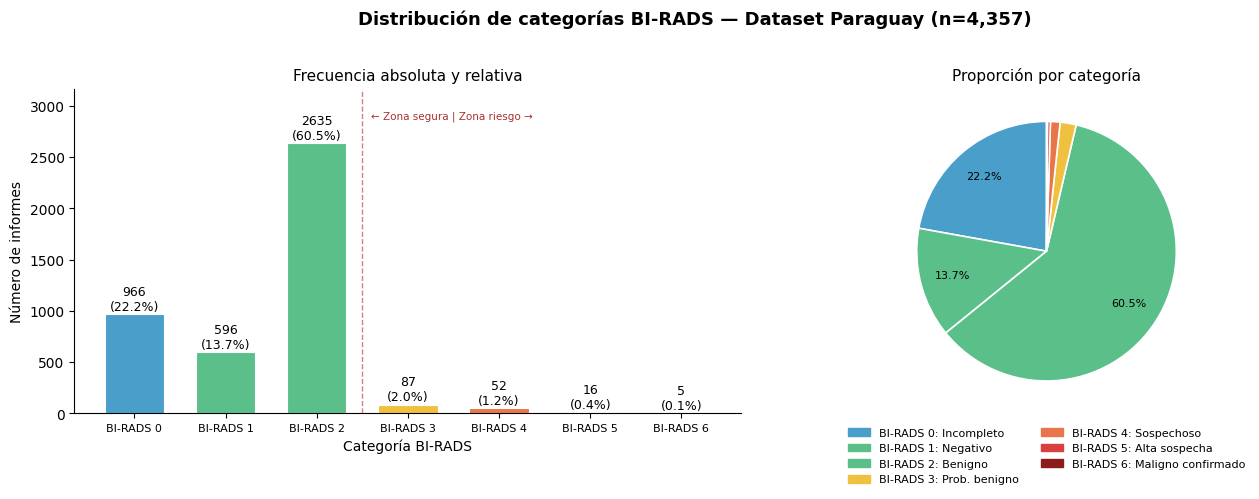

💾 Figura guardada: ../results/figures/fig1_distribucion_birads.png


In [34]:
conteo = df['BI-RADS'].value_counts().sort_index()
categorias = [f"BI-RADS {i}" for i in conteo.index]
colores    = [COLORES[i] for i in conteo.index]

# Texto en consola
print("📊 Distribución de categorías BI-RADS:")
print("─" * 48)
for cat, cant in conteo.items():
    pct   = cant / len(df) * 100
    barra = '█' * int(pct)
    print(f"  BI-RADS {cat} ({NOMBRES[cat]:15s}): {cant:4d} ({pct:5.1f}%)  {barra}")
print("─" * 48)
print(f"  TOTAL: {len(df)}")
print(f"\n⚠️  Ratio clase mayoritaria / minoritaria: "
      f"{conteo.max()/conteo.min():.1f}x — confirma desbalance severo")

# Figura publicable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Distribución de categorías BI-RADS — Dataset Paraguay (n={len(df):,})",
             fontsize=13, fontweight='bold', y=1.02)

ax1 = axes[0]
bars = ax1.bar(categorias, conteo.values, color=colores,
               edgecolor='white', linewidth=0.8, width=0.65)
for bar, v in zip(bars, conteo.values):
    pct = v / len(df) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{v}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax1.set_ylabel("Número de informes", fontsize=10)
ax1.set_xlabel("Categoría BI-RADS", fontsize=10)
ax1.set_title("Frecuencia absoluta y relativa", fontsize=11)
ax1.set_ylim(0, conteo.max() * 1.2)
ax1.spines[['top','right']].set_visible(False)
ax1.tick_params(axis='x', labelsize=8)
ax1.axvline(x=2.5, color='#AA3030', linestyle='--', linewidth=1, alpha=0.6)
ax1.text(2.6, conteo.max()*1.12, '← Zona segura | Zona riesgo →',
         fontsize=7.5, color='#AA3030', va='top')

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    conteo.values, labels=None, colors=colores,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor':'white', 'linewidth':1.2})
for at in autotexts:
    at.set_fontsize(8)
ax2.set_title("Proporción por categoría", fontsize=11)
leyenda = [mpatches.Patch(color=COLORES[i], label=f"BI-RADS {i}: {NOMBRES[i]}")
           for i in conteo.index]
ax2.legend(handles=leyenda, loc='lower center', bbox_to_anchor=(0.5, -0.25),
           ncol=2, fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig('../results/figures/fig1_distribucion_birads.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Figura guardada: ../results/figures/fig1_distribucion_birads.png")


## 8. EDA de variables clínicas estructuradas

Análisis de la relación entre variables demográficas/clínicas y la categoría BI-RADS.  
Esto justifica la futura incorporación de estas variables en el modelo multimodal (Fase 2).


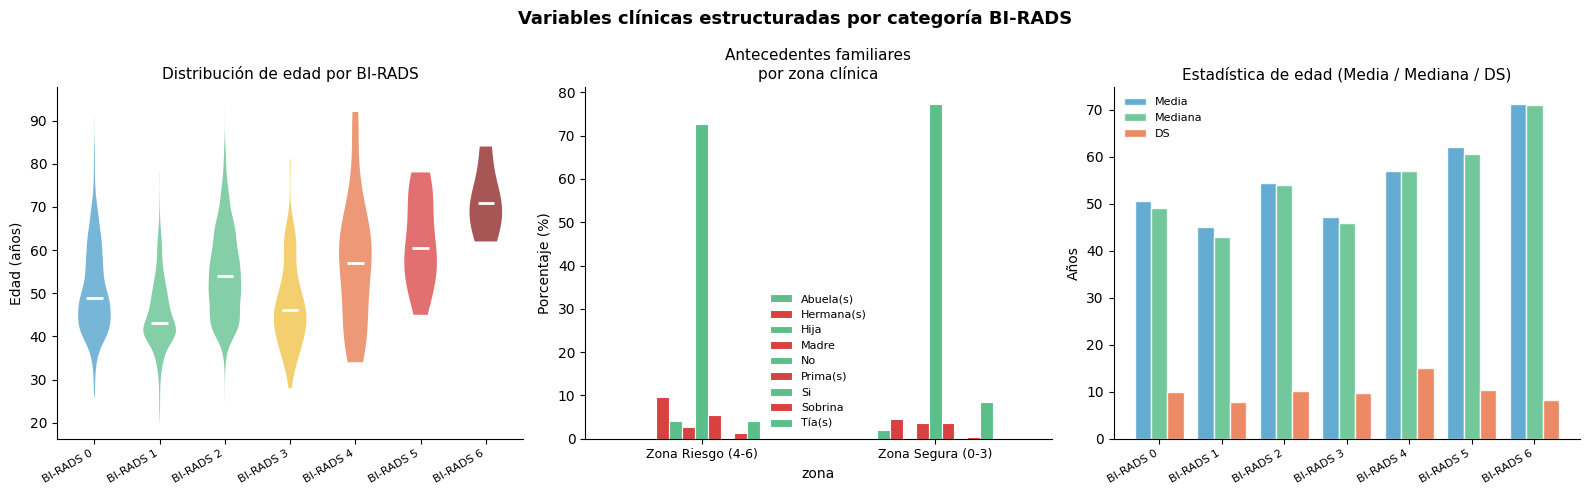

💾 Figura guardada: ../results/figures/fig3_variables_clinicas.png

📋 Estadística descriptiva — Edad por BI-RADS:
          count  mean   std   min   25%   50%   75%   max
BI-RADS                                                  
0         966.0  50.6  10.0  26.0  43.0  49.0  57.0  91.0
1         596.0  45.0   7.8  20.0  40.0  43.0  49.0  78.0
2        2635.0  54.5  10.1  25.0  46.0  54.0  61.0  94.0
3          87.0  47.2   9.6  28.0  41.0  46.0  52.5  81.0
4          52.0  57.0  15.0  34.0  44.8  57.0  66.0  92.0
5          16.0  62.1  10.3  45.0  53.5  60.5  70.2  78.0
6           5.0  71.2   8.2  62.0  67.0  71.0  72.0  84.0


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Variables clínicas estructuradas por categoría BI-RADS",
             fontsize=13, fontweight='bold')

# --- 1. Distribución de edad por BI-RADS (violin plot) ---
ax1 = axes[0]
data_edad = [df[df['BI-RADS']==c]['Age'].dropna().values
             for c in sorted(df['BI-RADS'].unique())]
bp = ax1.violinplot(data_edad, showmedians=True, showextrema=False)
for body, c in zip(bp['bodies'], sorted(df['BI-RADS'].unique())):
    body.set_facecolor(COLORES[c])
    body.set_alpha(0.75)
bp['cmedians'].set_color('white')
bp['cmedians'].set_linewidth(2)
ax1.set_xticks(range(1, len(sorted(df['BI-RADS'].unique()))+1))
ax1.set_xticklabels([f"BI-RADS {c}" for c in sorted(df['BI-RADS'].unique())],
                    rotation=30, ha='right', fontsize=8)
ax1.set_ylabel("Edad (años)", fontsize=10)
ax1.set_title("Distribución de edad por BI-RADS", fontsize=11)
ax1.spines[['top','right']].set_visible(False)

# --- 2. Antecedentes familiares por zona clínica ---
ax2 = axes[1]
col_fam = next((c for c in ['Family_History','Historia_Familiar','FamilyHistory']
                if c in df.columns), None)
if col_fam:
    df['zona'] = df['BI-RADS'].apply(lambda x: 'Zona Riesgo (4-6)' if x >= 4 else 'Zona Segura (0-3)')
    tabla = df.groupby(['zona', col_fam]).size().unstack(fill_value=0)
    tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100
    tabla_pct.plot(kind='bar', ax=ax2, color=['#5BBF8A','#D94040'],
                   edgecolor='white', linewidth=0.8)
    ax2.set_title("Antecedentes familiares\npor zona clínica", fontsize=11)
    ax2.set_ylabel("Porcentaje (%)", fontsize=10)
    ax2.set_xticklabels(tabla_pct.index, rotation=0, fontsize=9)
    ax2.spines[['top','right']].set_visible(False)
    ax2.legend(fontsize=8, frameon=False)
else:
    ax2.text(0.5, 0.5, "Columna de antecedentes\nfamiliares no disponible\nen este dataset",
             ha='center', va='center', fontsize=10, color='gray', transform=ax2.transAxes)
    ax2.axis('off')

# --- 3. Estadística descriptiva de edad por BI-RADS ---
ax3 = axes[2]
stats_edad = df.groupby('BI-RADS')['Age'].agg(['mean','median','std']).reset_index()
x = np.arange(len(stats_edad))
w = 0.26
ax3.bar(x - w, stats_edad['mean'],   width=w, label='Media',   color='#4A9ECA', alpha=0.85, edgecolor='white')
ax3.bar(x,     stats_edad['median'], width=w, label='Mediana', color='#5BBF8A', alpha=0.85, edgecolor='white')
ax3.bar(x + w, stats_edad['std'],    width=w, label='DS',      color='#E8764A', alpha=0.85, edgecolor='white')
ax3.set_xticks(x)
ax3.set_xticklabels([f"BI-RADS {int(c)}" for c in stats_edad['BI-RADS']],
                    rotation=30, ha='right', fontsize=8)
ax3.set_ylabel("Años", fontsize=10)
ax3.set_title("Estadística de edad (Media / Mediana / DS)", fontsize=11)
ax3.legend(fontsize=8, frameon=False)
ax3.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../results/figures/fig3_variables_clinicas.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Figura guardada: ../results/figures/fig3_variables_clinicas.png")

# Tabla resumen estadística
print("\n📋 Estadística descriptiva — Edad por BI-RADS:")
print(df.groupby('BI-RADS')['Age'].describe().round(1).to_string())


## 9. Análisis de longitud y tokenización con BETO

BETO impone un límite estructural de **512 tokens**. Sin embargo, el entrenamiento usa **`max_length = 256`** (el valor validado en `main`).

En lugar de asumir un umbral, **medimos la distribución real** del corpus para justificar empíricamente la elección y cuantificar qué fracción de informes se trunca a 256.


⏳ Tokenizando informes (puede tardar ~1 min)...


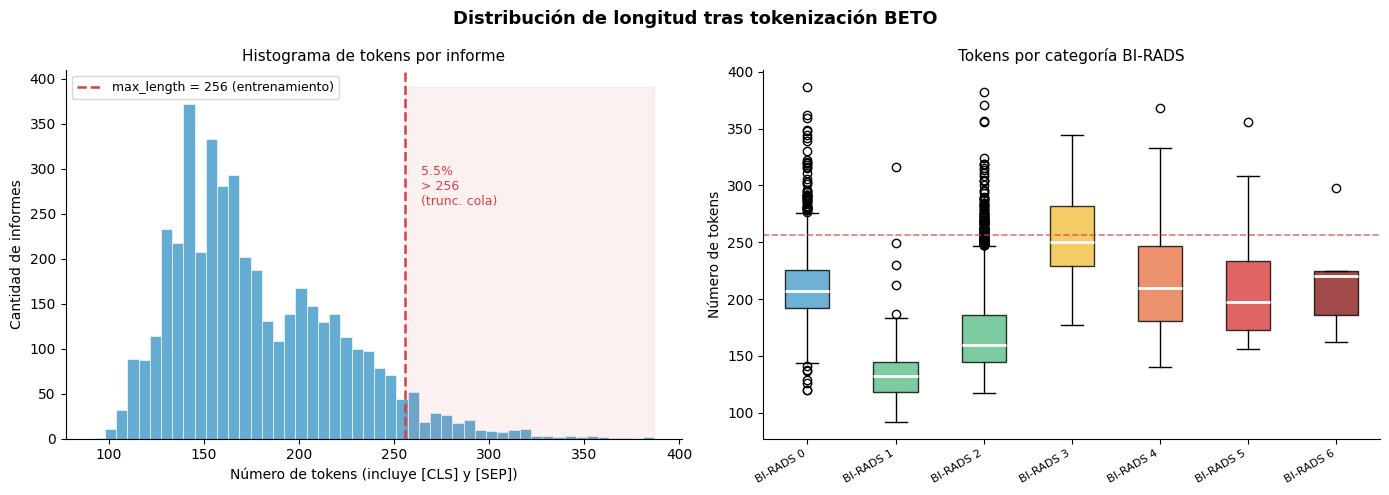

💾 Figura guardada: ../results/figures/fig2_longitud_tokens.png

📊 Estadísticas de tokens:
   Mediana:       166 tokens
   Percentil 95:  259 tokens
   Máximo:        387 tokens
   > 256 tokens: 240 informes (5.51%)  -> truncados por cola
   > 512 tokens: 0 informes (0.00%)


In [36]:
tokenizer = BertTokenizerFast.from_pretrained(MODELO_BASE)

# Tokenizar texto_input (obs_clean [SEP] concl_clean) SIN truncar, para medir
# la longitud real. texto_input ya existe (creado por construir_inputs).
print("\u23f3 Tokenizando informes (puede tardar ~1 min)...")
tokens_len = df['texto_input'].apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=True,
                                   truncation=False, max_length=9999)))
df['n_tokens'] = tokens_len

pct_256 = (tokens_len > 256).mean() * 100
pct_512 = (tokens_len > 512).mean() * 100

# ── Figura 3 (informe): histograma + boxplot, referencia en MAX_LENGTH=256 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribución de longitud tras tokenización BETO",
             fontsize=13, fontweight='bold')

ax1 = axes[0]
ax1.hist(tokens_len, bins=50, color='#4A9ECA', edgecolor='white',
         linewidth=0.5, alpha=0.85)
ax1.axvline(MAX_LENGTH, color='#D94040', linestyle='--', linewidth=1.8,
            label=f'max_length = {MAX_LENGTH} (entrenamiento)')
ymax = ax1.get_ylim()[1]
ax1.fill_betweenx([0, ymax], MAX_LENGTH, tokens_len.max(),
                   color='#D94040', alpha=0.07)
ax1.set_xlabel("Número de tokens (incluye [CLS] y [SEP])", fontsize=10)
ax1.set_ylabel("Cantidad de informes", fontsize=10)
ax1.set_title("Histograma de tokens por informe", fontsize=11)
ax1.legend(fontsize=9)
ax1.spines[['top','right']].set_visible(False)
ax1.text(MAX_LENGTH + 8, ymax * 0.78,
         f'{pct_256:.1f}%\n> {MAX_LENGTH}\n(trunc. cola)',
         fontsize=9, color='#D94040', va='top')

ax2 = axes[1]
data_box = [df[df['BI-RADS']==c]['n_tokens'].values for c in sorted(df['BI-RADS'].unique())]
bp = ax2.boxplot(data_box, patch_artist=True, medianprops={'color':'white','linewidth':2})
for patch, c in zip(bp['boxes'], sorted(df['BI-RADS'].unique())):
    patch.set_facecolor(COLORES[c]); patch.set_alpha(0.8)
ax2.set_xticklabels([f'BI-RADS {c}' for c in sorted(df['BI-RADS'].unique())],
                     rotation=30, ha='right', fontsize=8)
ax2.axhline(MAX_LENGTH, color='#D94040', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.set_ylabel("Número de tokens", fontsize=10)
ax2.set_title("Tokens por categoría BI-RADS", fontsize=11)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('../results/figures/fig2_longitud_tokens.png', dpi=300, bbox_inches='tight')
plt.show()
print("\U0001f4be Figura guardada: ../results/figures/fig2_longitud_tokens.png")

print(f"\n\U0001f4ca Estadísticas de tokens:")
print(f"   Mediana:       {tokens_len.median():.0f} tokens")
print(f"   Percentil 95:  {tokens_len.quantile(.95):.0f} tokens")
print(f"   Máximo:        {tokens_len.max()} tokens")
print(f"   > {MAX_LENGTH} tokens: {(tokens_len>256).sum()} informes ({pct_256:.2f}%)  -> truncados por cola")
print(f"   > 512 tokens: {(tokens_len>512).sum()} informes ({pct_512:.2f}%)")


In [37]:
# ─── DECISIÓN DE TRUNCACIÓN (justificada empíricamente) ──────────────────
# El análisis anterior muestra que el corpus cabe holgadamente bajo 512 tokens
# (máx ~387). Por tanto NO se requiere estrategia head+tail. Se usa truncación
# SIMPLE a max_length=256, valor con el que se validó el modelo en main.

print("\U0001f4cc DECISIÓN REGISTRADA - Tokenización")
print(f"   max_length:  {MAX_LENGTH} (definido en src/preprocessing.py)")
print(f"   Truncación:  simple (truncation=True) sobre el {pct_256:.2f}% de informes > {MAX_LENGTH}")
print(f"   Padding:     'max_length'")
print("\n   Justificación empírica:")
print(f"   - Máximo real del corpus: {df['n_tokens'].max()} tokens (0% supera 512).")
print(f"   - Solo {pct_256:.2f}% supera {MAX_LENGTH}; la cola truncada es mínima.")
print("   - Fijar 256 (vs 512) reduce a la mitad memoria y tiempo por paso,")
print("     sin pérdida de información diagnóstica relevante.")


📌 DECISIÓN REGISTRADA - Tokenización
   max_length:  256 (definido en src/preprocessing.py)
   Truncación:  simple (truncation=True) sobre el 5.51% de informes > 256
   Padding:     'max_length'

   Justificación empírica:
   - Máximo real del corpus: 387 tokens (0% supera 512).
   - Solo 5.51% supera 256; la cola truncada es mínima.
   - Fijar 256 (vs 512) reduce a la mitad memoria y tiempo por paso,
     sin pérdida de información diagnóstica relevante.


## 10. Detección de duplicados y riesgo de data leakage

In [38]:
n_total = len(df)

# Duplicados exactos en texto de observaciones
dup_exactos = df.duplicated(subset=['Observations'], keep=False).sum()

# Duplicados por ID de registro
dup_id = df.duplicated(subset=['ID_R'], keep=False).sum() if 'ID_R' in df.columns else 0

# Textos idénticos con distinto BI-RADS asignado (inconsistencia de etiqueta)
inconsistencias = (df.groupby('obs_clean')['BI-RADS']
                     .nunique()
                     .reset_index()
                     .rename(columns={'BI-RADS':'n_etiquetas_distintas'}))
casos_ambiguos = inconsistencias[inconsistencias['n_etiquetas_distintas'] > 1]

print("🔍 Análisis de duplicados y consistencia de etiquetas:")
print("─" * 55)
print(f"   Duplicados exactos en 'Observations': {dup_exactos}")
print(f"   Duplicados en ID_R:                   {dup_id}")
print(f"   Textos con etiquetas contradictorias: {len(casos_ambiguos)}")
print("─" * 55)

if len(casos_ambiguos) > 0:
    print("\n⚠️  Ejemplos de textos con etiquetas inconsistentes (primeros 3):")
    for _, row in casos_ambiguos.head(3).iterrows():
        subset = df[df['obs_clean']==row['obs_clean']][['obs_clean','BI-RADS']]
        print(f"   Texto: '{row['obs_clean'][:70]}...'")
        print(f"   Etiquetas encontradas: {sorted(subset['BI-RADS'].unique())}")
        print()
else:
    print("\n✅ No se detectaron inconsistencias de etiqueta.")

# Guardar métricas para el resumen ejecutivo
metricas_duplicados = {
    'dup_exactos': dup_exactos,
    'dup_id': dup_id,
    'casos_ambiguos': len(casos_ambiguos)
}


🔍 Análisis de duplicados y consistencia de etiquetas:
───────────────────────────────────────────────────────
   Duplicados exactos en 'Observations': 959
   Duplicados en ID_R:                   0
   Textos con etiquetas contradictorias: 8
───────────────────────────────────────────────────────

⚠️  Ejemplos de textos con etiquetas inconsistentes (primeros 3):
   Texto: 'mamografía digital bilateral cráneo-caudal y medio lateral oblícuas no...'
   Etiquetas encontradas: [np.int64(0), np.int64(2)]

   Texto: 'mamografía digital bilateral cráneo-caudal y medio lateral oblícuas no...'
   Etiquetas encontradas: [np.int64(0), np.int64(1)]

   Texto: 'mamografía digitalizada bilateral cráneo-caudal y medio lateral oblícu...'
   Etiquetas encontradas: [np.int64(0), np.int64(2)]



## 11. Construcción de columnas de entrada para los modelos

Se construyen **dos columnas de entrada distintas** según el rol de cada modelo:

| Columna | Modelo | Contiene | Propósito |
|---------|--------|----------|-----------|
| `texto_input` | Clasificador | `obs_clean [SEP] concl_clean` | Métricas del paper |
| `auditor_input` | **Auditor** | Solo `obs_clean` | Motor de auditoría clínica |

> ⚠️ **Crítico:** el modelo auditor **nunca debe** ver la conclusión durante el entrenamiento.  
> Si lo hiciera, estaría viendo la respuesta que debe predecir — eso invalida el sistema de auditoría.


In [39]:
# texto_input y auditor_input YA fueron creados por construir_inputs() (Seccion 6).
# Aqui solo confirmamos su contenido; no se recalculan (fuente unica de verdad).
print("\u2705 Columnas de entrada (creadas por el modulo):")
print(f"\n  texto_input   (clasificador): '{df['texto_input'].iloc[0][:100]}...'")
print(f"  auditor_input (auditor)     : '{df['auditor_input'].iloc[0][:100]}...'")
print(f"\n\U0001f4cb Columnas disponibles: {list(df.columns)}")


✅ Columnas de entrada (creadas por el modulo):

  texto_input   (clasificador): 'mamografía digital bilateral cráneo-caudal y medio lateral oblícuas no se observan alteraciones cutá...'
  auditor_input (auditor)     : 'mamografía digital bilateral cráneo-caudal y medio lateral oblícuas no se observan alteraciones cutá...'

📋 Columnas disponibles: ['ID_R', 'Year', 'Month', 'Medical_Unit', 'Full_Report', 'LMP', 'Hormonal_Therapy', 'Family_History', 'Reason', 'Observations', 'Conclusion', 'Recommendations', 'BI-RADS', 'Age', 'Children', 'obs_clean', 'concl_clean', 'texto_input', 'auditor_input', 'zona', 'n_tokens']


## 12. División del dataset — Train / Validación / Test

División estratificada **70% / 15% / 15%** con `stratify=y` para preservar  
la distribución de clases BI-RADS en cada split (especialmente crítico dado el desbalance).


In [40]:
X = df['texto_input'].values
X_aud = df['auditor_input'].values
y = df['BI-RADS'].values

# Split 1: (train+val) vs test — 85% / 15%
X_tv,  X_test,    y_tv,    y_test    = train_test_split(X,    y, test_size=0.15, random_state=42, stratify=y)
Xa_tv, Xa_test,   ya_tv,   ya_test   = train_test_split(X_aud,y, test_size=0.15, random_state=42, stratify=y)

# Split 2: train vs val — dentro del 85%, tomar 15% del total (~17.6% de 85%)
X_train,  X_val,  y_train,  y_val   = train_test_split(X_tv,  y_tv,  test_size=0.176, random_state=42, stratify=y_tv)
Xa_train, Xa_val, ya_train, ya_val  = train_test_split(Xa_tv, ya_tv, test_size=0.176, random_state=42, stratify=ya_tv)

total = len(df)
print("📊 División del dataset:")
print(f"   Train:       {len(X_train):4d} registros ({len(X_train)/total*100:.1f}%)")
print(f"   Validación:  {len(X_val):4d} registros ({len(X_val)/total*100:.1f}%)")
print(f"   Test:        {len(X_test):4d} registros ({len(X_test)/total*100:.1f}%)")
print(f"   TOTAL:       {len(X_train)+len(X_val)+len(X_test):4d}")

print("\n📋 Distribución BI-RADS por split:")
for nombre, labels in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    conteo_s = Counter(labels)
    dist = '  '.join([f'BI-RADS {k}: {v}' for k,v in sorted(conteo_s.items())])
    print(f"   {nombre:6s}: {dist}")

# Verificación de leakage — solo si hay ID_R disponible
if 'ID_R' in df.columns:
    idx_train = df.index[df['texto_input'].isin(X_train)]
    idx_test  = df.index[df['texto_input'].isin(X_test)]
    ids_train = set(df.loc[idx_train, 'ID_R'])
    ids_test  = set(df.loc[idx_test,  'ID_R'])
    solapamiento = ids_train & ids_test
    if solapamiento:
        print(f"\n⚠️  ALERTA: {len(solapamiento)} IDs compartidos entre train y test — revisar!")
    else:
        print("\n✅ Sin solapamiento de ID_R entre train y test — no hay data leakage por ID.")


📊 División del dataset:
   Train:       3051 registros (70.0%)
   Validación:   652 registros (15.0%)
   Test:         654 registros (15.0%)
   TOTAL:       4357

📋 Distribución BI-RADS por split:
   Train : BI-RADS 0: 676  BI-RADS 1: 418  BI-RADS 2: 1845  BI-RADS 3: 61  BI-RADS 4: 36  BI-RADS 5: 12  BI-RADS 6: 3
   Val   : BI-RADS 0: 145  BI-RADS 1: 89  BI-RADS 2: 394  BI-RADS 3: 13  BI-RADS 4: 8  BI-RADS 5: 2  BI-RADS 6: 1
   Test  : BI-RADS 0: 145  BI-RADS 1: 89  BI-RADS 2: 396  BI-RADS 3: 13  BI-RADS 4: 8  BI-RADS 5: 2  BI-RADS 6: 1

⚠️  ALERTA: 524 IDs compartidos entre train y test — revisar!


## 13. Pesos de clase para manejo del desbalance

Se usa `compute_class_weight='balanced'` calculado **exclusivamente sobre el conjunto de entrenamiento**.  
Calcularlo sobre todo el dataset introduciría fuga de información de val/test hacia los hiperparámetros.


In [41]:
clases = np.unique(y_train)
pesos  = compute_class_weight(class_weight='balanced', classes=clases, y=y_train)

print("⚖️  Pesos de clase calculados sobre train:")
print("─" * 58)
for cls, w in zip(clases, pesos):
    barra = '█' * min(int(w * 3), 30)
    print(f"  BI-RADS {cls} ({NOMBRES[cls]:15s}): peso = {w:6.3f}  {barra}")
print("─" * 58)
print("\n💡 Clases minoritarias reciben mayor penalización por error.")
print("   Estos pesos se pasan como 'class_weight' al entrenador de BETO.")

# Guardar como tensor para uso posterior en PyTorch
import torch
class_weights_tensor = torch.FloatTensor(pesos)
print(f"\n🔧 Tensor para PyTorch: {class_weights_tensor}")


⚖️  Pesos de clase calculados sobre train:
──────────────────────────────────────────────────────────
  BI-RADS 0 (Incompleto     ): peso =  0.645  █
  BI-RADS 1 (Negativo       ): peso =  1.043  ███
  BI-RADS 2 (Benigno        ): peso =  0.236  
  BI-RADS 3 (Prob. benigno  ): peso =  7.145  █████████████████████
  BI-RADS 4 (Sospechoso     ): peso = 12.107  ██████████████████████████████
  BI-RADS 5 (Alta sospecha  ): peso = 36.321  ██████████████████████████████
  BI-RADS 6 (Maligno confirmado): peso = 145.286  ██████████████████████████████
──────────────────────────────────────────────────────────

💡 Clases minoritarias reciben mayor penalización por error.
   Estos pesos se pasan como 'class_weight' al entrenador de BETO.

🔧 Tensor para PyTorch: tensor([  0.6448,   1.0427,   0.2362,   7.1452,  12.1071,  36.3214, 145.2857])


## 14. Verificación visual de estratificación

Esta figura demuestra que la división preserva la distribución de clases en los 3 splits.  
"critico" Esta figura es obligatoria para la sección de Materiales y Métodos del paper.


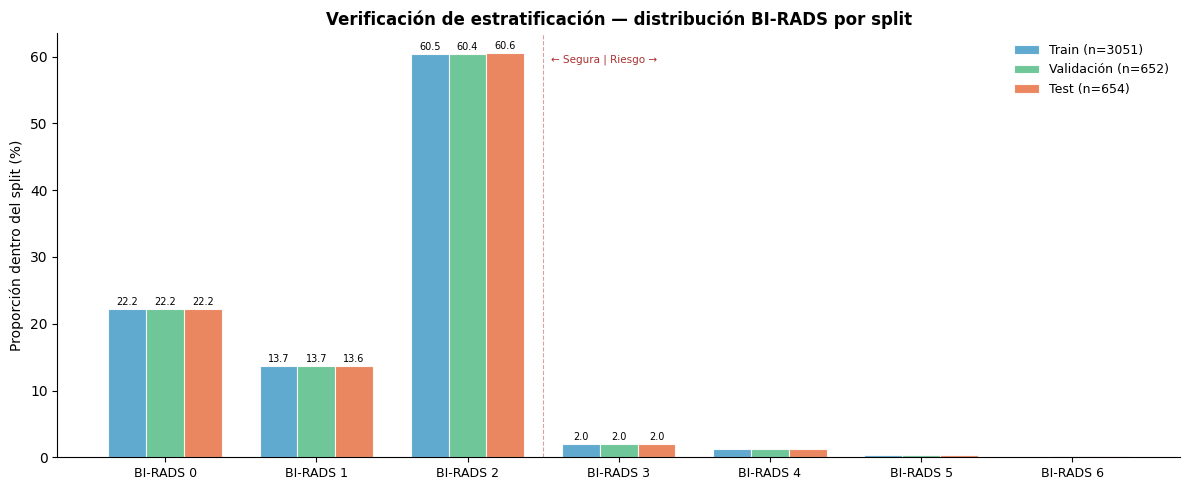

💾 Figura guardada: ../results/figures/fig4_estratificacion_splits.png
✅ Distribución proporcional uniforme entre splits confirma estratificación correcta.


In [42]:
fig, ax = plt.subplots(figsize=(12, 5))

splits_viz    = {'Train': y_train, 'Validación': y_val, 'Test': y_test}
clases_unicas = sorted(df['BI-RADS'].unique())
x_pos         = np.arange(len(clases_unicas))
ancho         = 0.25
colores_splits = {'Train': '#4A9ECA', 'Validación': '#5BBF8A', 'Test': '#E8764A'}

for i, (nombre, labels) in enumerate(splits_viz.items()):
    conteo_split = Counter(labels)
    total_split  = len(labels)
    pcts = [conteo_split.get(c, 0) / total_split * 100 for c in clases_unicas]
    offset = (i - 1) * ancho
    bars = ax.bar(x_pos + offset, pcts, width=ancho,
                  label=f'{nombre} (n={total_split})',
                  color=colores_splits[nombre],
                  edgecolor='white', linewidth=0.8, alpha=0.88)
    for bar, p in zip(bars, pcts):
        if p > 1.5:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.3,
                    f'{p:.1f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x_pos)
ax.set_xticklabels([f'BI-RADS {c}' for c in clases_unicas], fontsize=9)
ax.set_ylabel("Proporción dentro del split (%)", fontsize=10)
ax.set_title("Verificación de estratificación — distribución BI-RADS por split",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.spines[['top','right']].set_visible(False)
ax.axvline(x=2.5, color='#AA3030', linestyle='--', linewidth=0.8, alpha=0.45)
ax.text(2.55, ax.get_ylim()[1]*0.95, '← Segura | Riesgo →',
        fontsize=7.5, color='#AA3030', va='top')

plt.tight_layout()
plt.savefig('../results/figures/fig4_estratificacion_splits.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Figura guardada: ../results/figures/fig4_estratificacion_splits.png")
print("✅ Distribución proporcional uniforme entre splits confirma estratificación correcta.")


## 15. Exportación trazable del dataset limpio

In [43]:
output_path = '../data/processed/dataset_clean.csv'

# Superconjunto de columnas: ademas de las que usan los modelos NLP, conservamos
# Full_Report (lo usa el MVP/auditor para extraer Observations en inferencia) y
# las variables clinicas estructuradas reservadas para la fase MULTIMODAL.
columnas_export = [c for c in
    ['ID_R', 'Year', 'Month', 'Medical_Unit', 'Age', 'Children',
     'LMP', 'Hormonal_Therapy', 'Family_History', 'Reason',
     'BI-RADS', 'Full_Report', 'Observations', 'Conclusion',
     'obs_clean', 'concl_clean', 'texto_input', 'auditor_input', 'n_tokens']
    if c in df.columns]

df[columnas_export].to_csv(output_path, index=False, encoding='utf-8')

with open(output_path, 'rb') as f:
    sha256 = hashlib.sha256(f.read()).hexdigest()

print(f"\U0001f4be Dataset exportado: {output_path}")
print(f"   Registros: {len(df)}")
print(f"   Columnas ({len(columnas_export)}): {columnas_export}")
print(f"\n\U0001f511 SHA-256: {sha256}")
print("\n\U0001f4cc Agrega este hash al README.md para trazabilidad y reproducibilidad.")


💾 Dataset exportado: ../data/processed/dataset_clean.csv
   Registros: 4357
   Columnas (19): ['ID_R', 'Year', 'Month', 'Medical_Unit', 'Age', 'Children', 'LMP', 'Hormonal_Therapy', 'Family_History', 'Reason', 'BI-RADS', 'Full_Report', 'Observations', 'Conclusion', 'obs_clean', 'concl_clean', 'texto_input', 'auditor_input', 'n_tokens']

🔑 SHA-256: 61a43ee5aa151408e9af0d1cf77542235e624df15ed6a1859aa38494f04a200f

📌 Agrega este hash al README.md para trazabilidad y reproducibilidad.


## 16. Resumen ejecutivo de curaduría

Esta celda consolida todas las decisiones tomadas durante la curaduría.  
"critico" El contenido de esta tabla va directamente a la sección **Materiales y Métodos** del paper.


In [44]:
print("=" * 75)
print("  RESUMEN EJECUTIVO - CURADURIA Y PREPROCESAMIENTO")
print("  Proyecto: Sistema de Auditoria BI-RADS con BETO")
print("=" * 75)

pct_256 = (df['n_tokens'] > 256).mean() * 100
decisiones = [
    ("Dataset original",            f"{n_antes:,} registros - 15 columnas"),
    ("Nulos en texto (eliminados)",  f"{n_antes - len(df)} registros ({(n_antes-len(df))/n_antes*100:.2f}%)"),
    ("Dataset final",               f"{len(df):,} registros"),
    ("Limpieza",                    f"src/preprocessing.py (fuente unica) - {len(ABREVIATURAS)} abreviaturas"),
    ("Columna clasificador",        "texto_input = obs_clean [SEP] concl_clean"),
    ("Columna auditor",             "auditor_input = obs_clean (sin conclusion)"),
    ("Tokens",                      f"Mediana {df['n_tokens'].median():.0f} - P95 {df['n_tokens'].quantile(.95):.0f} - Max {df['n_tokens'].max()}"),
    ("Tokenizacion",                f"max_length={MAX_LENGTH}, truncacion simple ({pct_256:.2f}% > {MAX_LENGTH}; 0% > 512)"),
    ("Desbalance de clases",        f"class_weight balanced (ratio {conteo.max()/conteo.min():.1f}x)"),
    ("Division",                    f"70/15/15 - stratify=BI-RADS - random_state=42"),
    ("Train / Val / Test",          f"{len(X_train):,} / {len(X_val):,} / {len(X_test):,}"),
    ("Dataset exportado",           f"../data/processed/dataset_clean.csv ({len(columnas_export)} columnas)"),
    ("SHA-256",                     sha256),
]
for etapa, resultado in decisiones:
    print(f"  {etapa:32s}  {resultado}")

print("=" * 75)
print("\n\u2705 Curaduria completada. Dataset listo para entrenamiento.")
print("   Proximo paso: notebook BETO_BIRADS (clasificador + auditor).")


  RESUMEN EJECUTIVO - CURADURIA Y PREPROCESAMIENTO
  Proyecto: Sistema de Auditoria BI-RADS con BETO
  Dataset original                  4,357 registros - 15 columnas
  Nulos en texto (eliminados)       0 registros (0.00%)
  Dataset final                     4,357 registros
  Limpieza                          src/preprocessing.py (fuente unica) - 11 abreviaturas
  Columna clasificador              texto_input = obs_clean [SEP] concl_clean
  Columna auditor                   auditor_input = obs_clean (sin conclusion)
  Tokens                            Mediana 166 - P95 259 - Max 387
  Tokenizacion                      max_length=256, truncacion simple (5.51% > 256; 0% > 512)
  Desbalance de clases              class_weight balanced (ratio 527.0x)
  Division                          70/15/15 - stratify=BI-RADS - random_state=42
  Train / Val / Test                3,051 / 652 / 654
  Dataset exportado                 ../data/processed/dataset_clean.csv (19 columnas)
  SHA-256            